# Librería para análisis de imágenes satelitales

In [ ]:
!pip -q install rasterio


In [ ]:
import os, glob
import numpy as np
import rasterio
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
import tensorflow.keras.backend as K
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import (Input, Conv2D, Conv2DTranspose, MaxPooling2D, Activation,
                                     concatenate, add, multiply, UpSampling2D)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

from sklearn.metrics import confusion_matrix

# BASE DE DATOS Amazon Forest RGB

In [ ]:
DATA_ROOT = "/content/drive/MyDrive/Colab/Geotermia/Amazon Forest Dataset"
print("Existe DATA_ROOT?:", os.path.exists(DATA_ROOT))
print("Contenido:", os.listdir(DATA_ROOT) if os.path.exists(DATA_ROOT) else "No encontrado")


Existe DATA_ROOT?: True
Contenido: ['Test', 'Validation', 'Training']


# Preprocesamiento

## Confirmar rutas

In [ ]:
train_dir = os.path.join(DATA_ROOT, "Training")
test_dir  = os.path.join(DATA_ROOT, "Test")

train_img_dir = os.path.join(train_dir, "images")
train_msk_dir = os.path.join(train_dir, "masks")

print("train_dir existe?:", os.path.exists(train_dir), train_dir)
print("test_dir existe?:", os.path.exists(test_dir), test_dir)

print("train_img_dir existe?:", os.path.exists(train_img_dir), train_img_dir)
print("train_msk_dir existe?:", os.path.exists(train_msk_dir), train_msk_dir)

test_img_dir_candidate = os.path.join(test_dir, "images")
test_img_dir = test_img_dir_candidate if os.path.exists(test_img_dir_candidate) else test_dir
print("test_img_dir:", test_img_dir, "| existe?:", os.path.exists(test_img_dir))


train_dir existe?: True /content/drive/MyDrive/Colab/Geotermia/Amazon Forest Dataset/Training
test_dir existe?: True /content/drive/MyDrive/Colab/Geotermia/Amazon Forest Dataset/Test
train_img_dir existe?: True /content/drive/MyDrive/Colab/Geotermia/Amazon Forest Dataset/Training/images
train_msk_dir existe?: True /content/drive/MyDrive/Colab/Geotermia/Amazon Forest Dataset/Training/masks
test_img_dir: /content/drive/MyDrive/Colab/Geotermia/Amazon Forest Dataset/Test | existe?: True


In [ ]:
train_imgs = sorted(glob.glob(os.path.join(train_img_dir, "*.tif*")))
assert len(train_imgs) > 0, "No encontré imágenes en Training/images"

img_path = train_imgs[0]
base = os.path.splitext(os.path.basename(img_path))[0]
mask_path = os.path.join(train_msk_dir, base + ".png")

print("Imagen:", os.path.basename(img_path))
print("Máscara:", os.path.basename(mask_path), "| existe?:", os.path.exists(mask_path))


Imagen: Amazon_1110.tiff_25.tiff
Máscara: Amazon_1110.tiff_25.png | existe?: True


In [ ]:
# Leer GeoTIFF
with rasterio.open(img_path) as src:
    img = src.read()
    meta = src.meta

# Pasar a (H, W, C)
img_hwc = np.transpose(img, (1, 2, 0)).astype(np.float32)

# Leer máscara PNG (escala de grises)
mask = np.array(Image.open(mask_path).convert("L"))

print("Meta GeoTIFF:", meta)
print("Shape imagen (C,H,W):", img.shape)
print("Shape imagen (H,W,C):", img_hwc.shape)
print("Shape máscara:", mask.shape)
print("Valores únicos máscara (muestra):", np.unique(mask)[:10])


Meta GeoTIFF: {'driver': 'GTiff', 'dtype': 'uint8', 'nodata': None, 'width': 512, 'height': 512, 'count': 3, 'crs': CRS.from_wkt('GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]]'), 'transform': Affine(9.119649793838669e-05, 0.0, -59.71893239305556,
       0.0, -8.991329589843819e-05, -9.587168649444445)}
Shape imagen (C,H,W): (3, 512, 512)
Shape imagen (H,W,C): (512, 512, 3)
Shape máscara: (512, 512)
Valores únicos máscara (muestra): [  0 255]


In [ ]:
mask_bin = (mask > 127).astype(np.uint8)

print("Unique máscara binaria:", np.unique(mask_bin))
print("¿Tamaños coinciden (H,W)?:", img_hwc.shape[:2] == mask_bin.shape)


Unique máscara binaria: [0 1]
¿Tamaños coinciden (H,W)?: True


# Dataloader


Conteos:
TRAIN pairs: 30
VAL pairs  : 15
TEST images: 15

Shapes finales:
X_train: (30, 512, 512, 3) float32 range: 0.0 1.0
Y_train: (30, 512, 512, 1) uint8 unique: [0 1]
X_val  : (15, 512, 512, 3) float32 range: 0.0 1.0
Y_val  : (15, 512, 512, 1) uint8 unique: [0 1]
X_test : (15, 512, 512, 3)


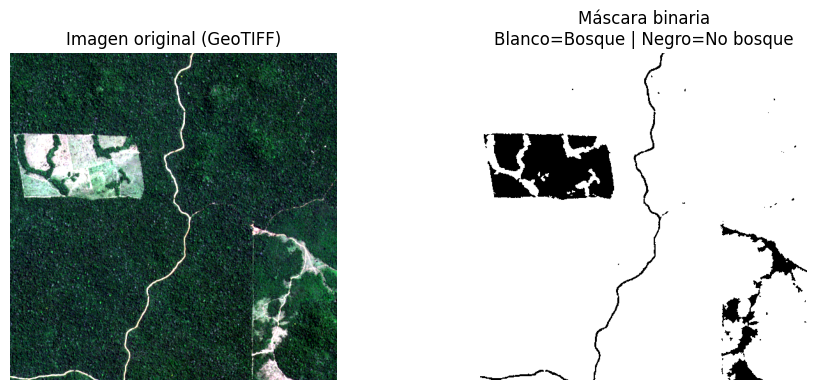

In [ ]:
TARGET_H, TARGET_W = 512, 512

def read_geotiff_rgb01(path):

    with rasterio.open(path) as src:
        img = src.read().astype(np.float32)

    if img.ndim != 3:
        raise ValueError(f"GeoTIFF inesperado: {path} con shape {img.shape}")

    C, H, W = img.shape


    if C >= 3:
        img = img[:3]
    elif C == 1:
        img = np.repeat(img, 3, axis=0)
    else:
        raise ValueError(f"Número de bandas no soportado: C={C} en {path}")

    # Normalización

    for c in range(3):
        p2, p98 = np.percentile(img[c], (2, 98))
        img[c] = (img[c] - p2) / (p98 - p2 + 1e-6)
        img[c] = np.clip(img[c], 0.0, 1.0)

    # (H,W,3)
    img = np.transpose(img, (1, 2, 0))


    if img.shape[0] != TARGET_H or img.shape[1] != TARGET_W:
        img_uint8 = (img * 255).astype(np.uint8)
        img_pil = Image.fromarray(img_uint8).resize((TARGET_W, TARGET_H), resample=Image.BILINEAR)
        img = np.array(img_pil).astype(np.float32) / 255.0

    return img.astype(np.float32)



def read_mask_bin(path):

    m = np.array(Image.open(path).convert("L"))

    if m.shape[0] != TARGET_H or m.shape[1] != TARGET_W:
        m_pil = Image.fromarray(m).resize((TARGET_W, TARGET_H), resample=Image.NEAREST)
        m = np.array(m_pil)

    m = (m > 127).astype(np.uint8)
    return m[..., None]



def pair_img_mask(img_dir, mask_dir):

    img_paths = sorted(glob.glob(os.path.join(img_dir, "*.tif*")))
    msk_paths = sorted(glob.glob(os.path.join(mask_dir, "*.png")))

    msk_dict = {os.path.splitext(os.path.basename(p))[0]: p for p in msk_paths}

    X_paths, Y_paths = [], []
    for ip in img_paths:
        key = os.path.splitext(os.path.basename(ip))[0]
        if key in msk_dict:
            X_paths.append(ip)
            Y_paths.append(msk_dict[key])

    return X_paths, Y_paths


# Emparejamiento train y val

train_img_paths, train_msk_paths = pair_img_mask(train_img_dir, train_msk_dir)
val_img_paths,   val_msk_paths   = pair_img_mask(val_img_dir, val_msk_dir)

test_img_paths = sorted(glob.glob(os.path.join(test_img_dir, "*.tif*")))

print("\nConteos:")
print("TRAIN pairs:", len(train_img_paths))
print("VAL pairs  :", len(val_img_paths))
print("TEST images:", len(test_img_paths))


# convertir a NumPy

training_images, training_masks = [], []
for ip, mp in zip(train_img_paths, train_msk_paths):
    training_images.append(read_geotiff_rgb01(ip))
    training_masks.append(read_mask_bin(mp))

validation_images, validation_masks = [], []
for ip, mp in zip(val_img_paths, val_msk_paths):
    validation_images.append(read_geotiff_rgb01(ip))
    validation_masks.append(read_mask_bin(mp))

test_images = []
for ip in test_img_paths:
    test_images.append(read_geotiff_rgb01(ip))


# Convertir a arrays

X_train = np.stack(training_images).astype("float32")
Y_train = np.stack(training_masks).astype("uint8")

X_val   = np.stack(validation_images).astype("float32")
Y_val   = np.stack(validation_masks).astype("uint8")

X_test  = np.stack(test_images).astype("float32") if len(test_images) else None

print("\nShapes finales:")
print("X_train:", X_train.shape, X_train.dtype, "range:", float(X_train.min()), float(X_train.max()))
print("Y_train:", Y_train.shape, Y_train.dtype, "unique:", np.unique(Y_train))
print("X_val  :", X_val.shape, X_val.dtype, "range:", float(X_val.min()), float(X_val.max()))
print("Y_val  :", Y_val.shape, Y_val.dtype, "unique:", np.unique(Y_val))
print("X_test :", None if X_test is None else X_test.shape)


# Visualización imágen original + máscara binaria

idx = 0

img = X_train[idx]
msk = Y_train[idx, ..., 0]

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.title("Imagen original (GeoTIFF)")
plt.imshow(img)
plt.axis("off")

plt.subplot(1,2,2)
plt.title("Máscara binaria\nBlanco=Bosque | Negro=No bosque")
plt.imshow(msk, cmap="gray")
plt.axis("off")

plt.tight_layout()
plt.show()

t_images: (30, 512, 512, 3) float32 0.0 1.0
t_masks : (30, 512, 512, 1) float32 [0. 1.]
v_images: (15, 512, 512, 3) float32 0.0 1.0
v_masks : (15, 512, 512, 1) float32 [0. 1.]
Batch shapes: (1, 512, 512, 3) (1, 512, 512, 1) mask unique: [0. 1.]


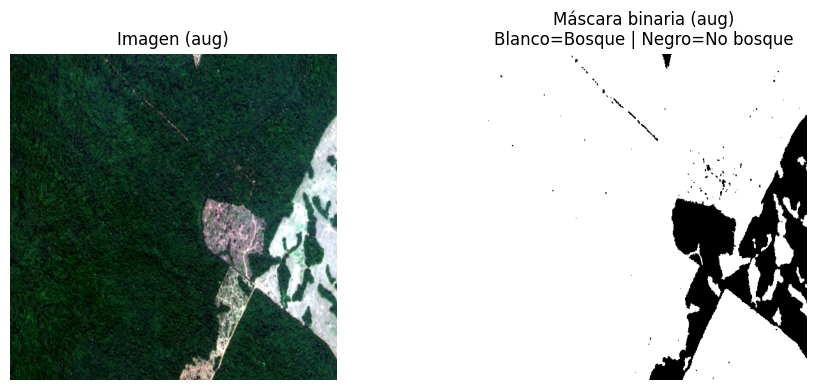

In [ ]:
# Arrays

t_images = X_train.astype("float32")   # (N,512,512,3) en [0,1]
t_masks  = Y_train.astype("float32")   # (N,512,512,1) en {0,1}

v_images = X_val.astype("float32")
v_masks  = Y_val.astype("float32")

print("t_images:", t_images.shape, t_images.dtype, float(t_images.min()), float(t_images.max()))
print("t_masks :", t_masks.shape,  t_masks.dtype,  np.unique(t_masks))
print("v_images:", v_images.shape, v_images.dtype, float(v_images.min()), float(v_images.max()))
print("v_masks :", v_masks.shape,  v_masks.dtype,  np.unique(v_masks))




def adjustData(img, mask, num_class=2):
    img = img.astype(np.float32)
    mask = (mask > 0.5).astype(np.float32)
    return img, mask


# Generador sincronizado

def trainGenerator(batch_size,
                   image_array,
                   mask_array,
                   aug_dict,
                   image_save_prefix="image",
                   mask_save_prefix="mask",
                   num_class=2,
                   save_to_dir=None,
                   target_size=(512,512),
                   seed=1):



    image_datagen = ImageDataGenerator(**aug_dict)
    mask_datagen  = ImageDataGenerator(**aug_dict)

    image_generator = image_datagen.flow(
        image_array,
        batch_size=batch_size,
        save_to_dir=save_to_dir,
        save_prefix=image_save_prefix,
        seed=seed,
        shuffle=True
    )

    mask_generator = mask_datagen.flow(
        mask_array,
        batch_size=batch_size,
        save_to_dir=save_to_dir,
        save_prefix=mask_save_prefix,
        seed=seed,
        shuffle=True
    )

    for (img, mask) in zip(image_generator, mask_generator):
        img, mask = adjustData(img, mask, num_class)
        yield (img, mask)

# Parámetros de augmentación

data_gen_args = dict(
    rotation_range=180,
    width_shift_range=0.25,
    height_shift_range=0.25,
    shear_range=0.25,
    zoom_range=0.25,
    horizontal_flip=True,
    vertical_flip=True,
    fill_mode="reflect",
)


# Crear generador de entrenamiento

train = trainGenerator(
    batch_size=1,
    image_array=t_images,
    mask_array=t_masks,
    aug_dict=data_gen_args,
    save_to_dir=None,
    seed=42
)


# Validation dataset

val_ds = tf.data.Dataset.from_tensor_slices((v_images, v_masks))
val_ds = val_ds.map(lambda x,y: (tf.cast(x, tf.float32), tf.cast(y > 0.5, tf.float32)))
val_ds = val_ds.batch(1).prefetch(tf.data.AUTOTUNE)


# Sanity check

x_batch, y_batch = next(train)

img = x_batch[0]
msk = y_batch[0, ..., 0]

print("Batch shapes:", x_batch.shape, y_batch.shape, "mask unique:", np.unique(msk))

plt.figure(figsize=(10,4))
plt.subplot(1,2,1); plt.title("Imagen (aug)"); plt.imshow(img); plt.axis("off")
plt.subplot(1,2,2); plt.title("Máscara binaria (aug)\nBlanco=Bosque | Negro=No bosque"); plt.imshow(msk, cmap="gray"); plt.axis("off")
plt.tight_layout()
plt.show()

# Entrenamiento con la red Attention Unet

In [ ]:
def convBlock(input, filters, kernel, kernel_init='he_normal', act='relu', transpose=False):
    if not transpose:
        conv = Conv2D(filters, kernel, padding='same', kernel_initializer=kernel_init)(input)
    else:
        conv = Conv2DTranspose(filters, kernel, padding='same', kernel_initializer=kernel_init)(input)
    conv = Activation(act)(conv)
    return conv

def convBlock2(input, filters, kernel, kernel_init='he_normal', act='relu', transpose=False):
    if not transpose:
        conv = Conv2D(filters, kernel, padding='same', kernel_initializer=kernel_init)(input)
        conv = Activation(act)(conv)
        conv = Conv2D(filters, kernel, padding='same', kernel_initializer=kernel_init)(conv)
        conv = Activation(act)(conv)
    else:
        conv = Conv2DTranspose(filters, kernel, padding='same', kernel_initializer=kernel_init)(input)
        conv = Activation(act)(conv)
        conv = Conv2DTranspose(filters, kernel, padding='same', kernel_initializer=kernel_init)(conv)
        conv = Activation(act)(conv)
    return conv


# Bloque de atención

def attention_block(x, gating, inter_shape, drop_rate=0.25):

    shape_x = K.int_shape(x)
    shape_g = K.int_shape(gating)

    # Transformación de x

    theta_x = Conv2D(inter_shape, 1, strides=1, padding='same',
                     kernel_initializer='he_normal', activation=None)(x)
    theta_x = MaxPooling2D((2,2))(theta_x)
    shape_theta_x = K.int_shape(theta_x)


    phi_g = Conv2D(inter_shape, 1, strides=1, padding='same',
                   kernel_initializer='he_normal', activation=None)(gating)


    concat_xg = add([phi_g, theta_x])
    act_xg = Activation('relu')(concat_xg)

    psi = Conv2D(1, 1, strides=1, padding='same',
                 kernel_initializer='he_normal', activation=None)(act_xg)
    sigmoid_xg = Activation('sigmoid')(psi)
    shape_sigmoid = K.int_shape(sigmoid_xg)

    upsample_psi = UpSampling2D(
        interpolation='bilinear',
        size=(shape_x[1] // shape_sigmoid[1], shape_x[2] // shape_sigmoid[2])
    )(sigmoid_xg)


    y = multiply([upsample_psi, x])

    return y

In [ ]:
def UNetAM(trained_weights=None, input_size=(512,512,3), drop_rate=0.25, lr=1e-4, filter_base=16):

    inputs = Input(input_size, batch_size=1)

    # Encoder
    conv = convBlock2(inputs, filter_base, 3)
    conv0 = MaxPooling2D((2,2))(conv)
    conv0 = convBlock2(conv0, 2*filter_base, 3)

    pool0 = MaxPooling2D((2,2))(conv0)
    conv1 = convBlock2(pool0, 4*filter_base, 3)

    pool1 = MaxPooling2D((2,2))(conv1)
    conv2 = convBlock2(pool1, 8*filter_base, 3)

    pool2 = MaxPooling2D((2,2))(conv2)
    conv3 = convBlock2(pool2, 16*filter_base, 3)

    # Decoder + atención

    up4 = Conv2DTranspose(8*filter_base, 2, strides=2, kernel_initializer='he_normal')(conv3)
    merge4 = attention_block(conv2, conv3, 8*filter_base, drop_rate)
    conv4 = concatenate([up4, merge4])
    conv4 = convBlock2(conv4, 8*filter_base, 3)

    up5 = Conv2DTranspose(4*filter_base, 2, strides=2, kernel_initializer='he_normal')(conv4)
    merge5 = attention_block(conv1, conv4, 4*filter_base, drop_rate)
    conv5 = concatenate([up5, merge5])
    conv5 = convBlock2(conv5, 4*filter_base, 3)

    up6 = Conv2DTranspose(2*filter_base, 2, strides=2, kernel_initializer='he_normal')(conv5)
    merge6 = attention_block(conv0, conv5, 2*filter_base, drop_rate)
    conv6 = concatenate([up6, merge6])
    conv6 = convBlock2(conv6, 2*filter_base, 3)

    up7 = Conv2DTranspose(1*filter_base, 2, strides=2, kernel_initializer='he_normal')(conv6)
    merge7 = attention_block(conv, conv6, 1*filter_base, drop_rate)
    conv7 = concatenate([up7, merge7])
    conv7 = convBlock2(conv7, 1*filter_base, 3)


    out = Conv2D(1, 1, activation='sigmoid', padding='same')(conv7)

    model = Model(inputs, out)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss='binary_crossentropy',
        metrics=['accuracy', 'mse']
    )

    if trained_weights is not None:
        model.load_weights(trained_weights)

    return model

In [ ]:
model_attunet = UNetAM(trained_weights=None, input_size=(512,512,3), lr=1e-4, filter_base=16)
model_attunet.summary()

ckpt_dir = "/content/drive/MyDrive/amazon_forest_checkpoints"
os.makedirs(ckpt_dir, exist_ok=True)

best_weights_path = os.path.join(ckpt_dir, "attunet_best_val_loss.weights.h5")
last_weights_path = os.path.join(ckpt_dir, "attunet_last.weights.h5")

callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=best_weights_path,
        monitor="val_loss",
        save_best_only=True,
        save_weights_only=True,
        mode="min",
        verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=15,
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1
    )
]

history_att = model_attunet.fit(
    X_train, Y_train,
    validation_data=(X_val, Y_val),
    batch_size=1,
    epochs=50,
    callbacks=callbacks,
    verbose=1
)

model_attunet.save_weights(last_weights_path)
print("\Mejor checkpoint:", best_weights_path)
print("Último estado    :", last_weights_path)

<>:44: SyntaxWarning: invalid escape sequence '\M'
<>:44: SyntaxWarning: invalid escape sequence '\M'
/tmp/ipython-input-1453089735.py:44: SyntaxWarning: invalid escape sequence '\M'
  print("\Mejor checkpoint:", best_weights_path)


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (1, 512, 512, 3)  │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_77 (Conv2D)  │ (1, 512, 512, 16) │        448 │ input_layer_5[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_70       │ (1, 512, 512, 16) │          0 │ conv2d_77[0][0]   │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_78 (Conv2D)  │ (1, 512, 512, 16) │      2,320 │ activation_70[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_71       │ (1, 512, 512, 16) │          0 │ conv2d_78[0][0]   │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_26    │ (1, 256, 256, 16) │          0 │ activation_71[0]… │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_79 (Conv2D)  │ (1, 256, 256, 32) │      4,640 │ max_pooling2d_26… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_72       │ (1, 256, 256, 32) │          0 │ conv2d_79[0][0]   │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_80 (Conv2D)  │ (1, 256, 256, 32) │      9,248 │ activation_72[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_73       │ (1, 256, 256, 32) │          0 │ conv2d_80[0][0]   │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_27    │ (1, 128, 128, 32) │          0 │ activation_73[0]… │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_81 (Conv2D)  │ (1, 128, 128, 64) │     18,496 │ max_pooling2d_27… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_74       │ (1, 128, 128, 64) │          0 │ conv2d_81[0][0]   │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_82 (Conv2D)  │ (1, 128, 128, 64) │     36,928 │ activation_74[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_75       │ (1, 128, 128, 64) │          0 │ conv2d_82[0][0]   │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_28    │ (1, 64, 64, 64)   │          0 │ activation_75[0]… │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_83 (Conv2D)  │ (1, 64, 64, 128)  │     73,856 │ max_pooling2d_28… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_76       │ (1, 64, 64, 128)  │          0 │ conv2d_83[0][0]   │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_84 (Conv2D)  │ (1, 64, 64, 128)  │    147,584 │ activation_76[0]… │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 2,007,109 (7.66 MB)

 Trainable params: 2,007,109 (7.66 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.5130 - loss: 0.6785 - mse: 0.2434
Epoch 1: val_loss improved from inf to 0.64948, saving model to /content/drive/MyDrive/amazon_forest_checkpoints/attunet_best_val_loss.weights.h5
30/30 ━━━━━━━━━━━━━━━━━━━━ 37s 245ms/step - accuracy: 0.5116 - loss: 0.6789 - mse: 0.2436 - val_accuracy: 0.6146 - val_loss: 0.6495 - val_mse: 0.2286 - learning_rate: 1.0000e-04
Epoch 2/50
29/30 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.5585 - loss: 0.6600 - mse: 0.2342
Epoch 2: val_loss improved from 0.64948 to 0.59771, saving model to /content/drive/MyDrive/amazon_forest_checkpoints/attunet_best_val_loss.weights.h5
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 62ms/step - accuracy: 0.5585 - loss: 0.6593 - mse: 0.2339 - val_accuracy: 0.6397 - val_loss: 0.5977 - val_mse: 0.2055 - learning_rate: 1.0000e-04
Epoch 3/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.5610 - loss: 0.6552 - mse: 0.2326
Epoch 3: val_loss improved from 0.59771 to 0.56980, s

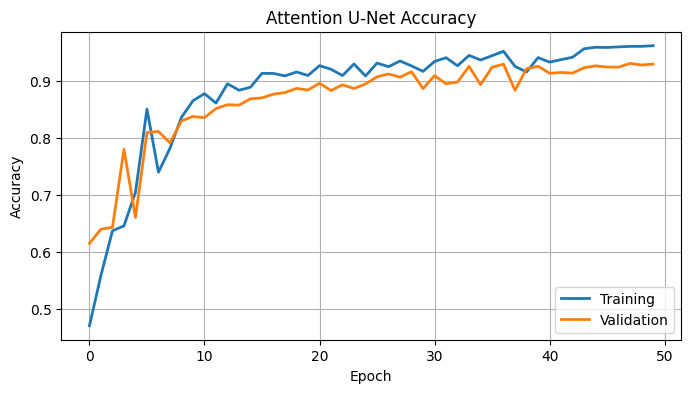

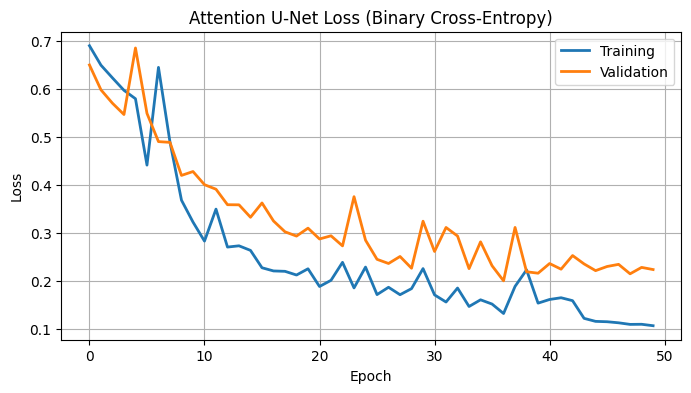

In [ ]:
plt.figure(figsize=(8,4))
plt.plot(history_att.history["accuracy"], linewidth=2)
plt.plot(history_att.history["val_accuracy"], linewidth=2)
plt.ylabel("Accuracy")
plt.xlabel("Epoch")
plt.legend(["Training", "Validation"], loc="lower right")
plt.grid(True)
plt.title("Attention U-Net Accuracy")
plt.show()

plt.figure(figsize=(8,4))
plt.plot(history_att.history["loss"], linewidth=2)
plt.plot(history_att.history["val_loss"], linewidth=2)
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.legend(["Training", "Validation"], loc="upper right")
plt.grid(True)
plt.title("Attention U-Net Loss (Binary Cross-Entropy)")
plt.show()

In [ ]:
def iou_score_flat(y_true_flat, y_pred_flat, smooth=1e-6):
    intersection = np.sum(y_true_flat * y_pred_flat)
    union = np.sum(y_true_flat) + np.sum(y_pred_flat) - intersection
    return (intersection + smooth) / (union + smooth)

def evaluate_segmentation_metrics(model, X, Y, threshold=0.5):
    preds = model.predict(X, verbose=0)
    preds_bin = (preds > threshold).astype(np.uint8)
    Y_bin = (Y > 0.5).astype(np.uint8)

    y_pred = preds_bin.flatten()
    y_true = Y_bin.flatten()

    return {
        "accuracy":  accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall":    recall_score(y_true, y_pred, zero_division=0),
        "f1_score":  f1_score(y_true, y_pred, zero_division=0),
        "iou":       iou_score_flat(y_true, y_pred),
    }


model_attunet.load_weights(best_weights_path)

train_metrics_att = evaluate_segmentation_metrics(model_attunet, X_train, Y_train, threshold=0.5)
val_metrics_att   = evaluate_segmentation_metrics(model_attunet, X_val,   Y_val,   threshold=0.5)

print("\Métricas Attention U-Net TRAIN:")
for k, v in train_metrics_att.items():
    print(f"  {k:10s}: {v:.4f}")

print("\Métricas Attention U-Net VAL:")
for k, v in val_metrics_att.items():
    print(f"  {k:10s}: {v:.4f}")

<>:28: SyntaxWarning: invalid escape sequence '\M'
<>:32: SyntaxWarning: invalid escape sequence '\M'
<>:28: SyntaxWarning: invalid escape sequence '\M'
<>:32: SyntaxWarning: invalid escape sequence '\M'
/tmp/ipython-input-13534939.py:28: SyntaxWarning: invalid escape sequence '\M'
  print("\Métricas Attention U-Net TRAIN:")
/tmp/ipython-input-13534939.py:32: SyntaxWarning: invalid escape sequence '\M'
  print("\Métricas Attention U-Net VAL:")


\Métricas Attention U-Net TRAIN:
  accuracy  : 0.9472
  precision : 0.9714
  recall    : 0.9287
  f1_score  : 0.9496
  iou       : 0.9040
\Métricas Attention U-Net VAL:
  accuracy  : 0.9291
  precision : 0.9119
  recall    : 0.9426
  f1_score  : 0.9270
  iou       : 0.8639


# Matriz de confusión-Pixel

In [ ]:
# Umbral usado en evaluación
threshold = 0.5

# Predicciones en validación
preds = model_attunet.predict(X_val, verbose=0)
preds_bin = (preds > threshold).astype(np.uint8)

# Ground truth
y_true = (Y_val > 0.5).astype(np.uint8)


y_true_flat = y_true.flatten()
y_pred_flat = preds_bin.flatten()

# Matriz de confusión
cm = confusion_matrix(y_true_flat, y_pred_flat)
tn, fp, fn, tp = cm.ravel()

print("Confusion Matrix (pixel-wise):")
print(cm)
print(f"\nTN: {tn}\nFP: {fp}\nFN: {fn}\nTP: {tp}")

Confusion Matrix (pixel-wise):
[[1882292  171085]
 [ 107881 1770902]]

TN: 1882292
FP: 171085
FN: 107881
TP: 1770902


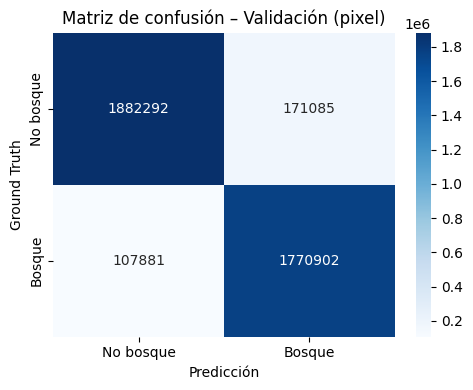

In [ ]:
plt.figure(figsize=(5,4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No bosque", "Bosque"],
    yticklabels=["No bosque", "Bosque"]
)

plt.xlabel("Predicción")
plt.ylabel("Ground Truth")
plt.title("Matriz de confusión – Validación (pixel)")
plt.tight_layout()
plt.show()

# Matriz de confusión normalizada

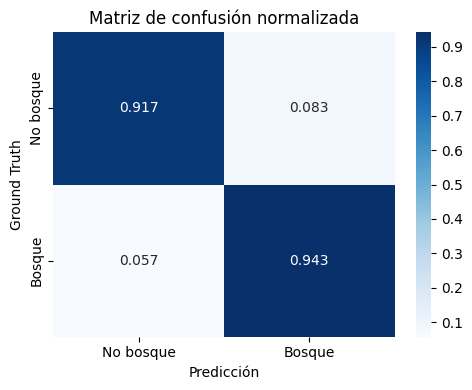

In [ ]:
cm_norm = cm.astype("float") / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(5,4))
sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".3f",
    cmap="Blues",
    xticklabels=["No bosque", "Bosque"],
    yticklabels=["No bosque", "Bosque"]
)

plt.xlabel("Predicción")
plt.ylabel("Ground Truth")
plt.title("Matriz de confusión normalizada")
plt.tight_layout()
plt.show()

# Visualización de algunas imágenes de validación

In [ ]:
def visualize_validation_examples(model, X_val, Y_val, indices, threshold=0.5):

    for idx in indices:
        img = X_val[idx]
        gt  = Y_val[idx, ..., 0]

        pred = model.predict(X_val[idx:idx+1], verbose=0)[0, ..., 0]
        pred_bin = (pred > threshold).astype(np.uint8)

        plt.figure(figsize=(12,4))

        plt.subplot(1,3,1)
        plt.title("Imagen original")
        plt.imshow(img)
        plt.axis("off")

        plt.subplot(1,3,2)
        plt.title("Ground Truth")
        plt.imshow(gt, cmap="gray")
        plt.axis("off")

        plt.subplot(1,3,3)
        plt.title("Prediction U-Net")
        plt.imshow(pred_bin, cmap="gray")
        plt.axis("off")

        plt.suptitle(f"{idx}", fontsize=12)
        plt.tight_layout()
        plt.show()


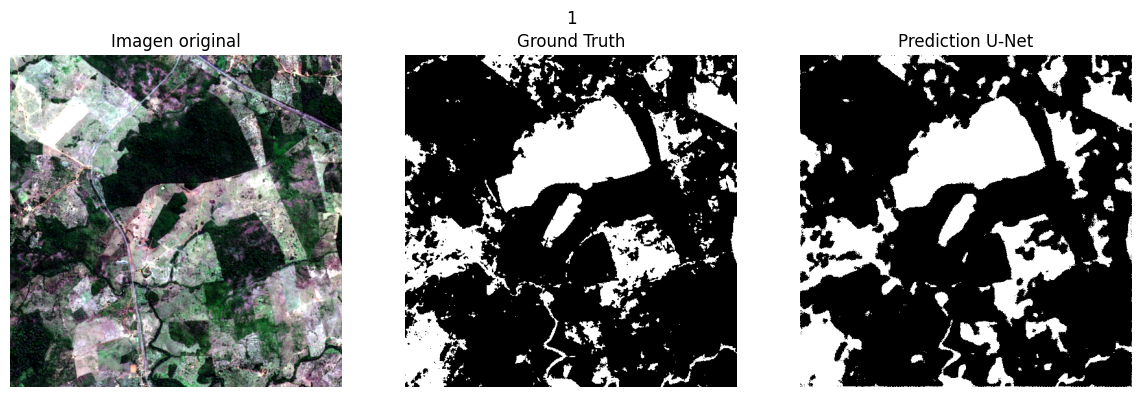

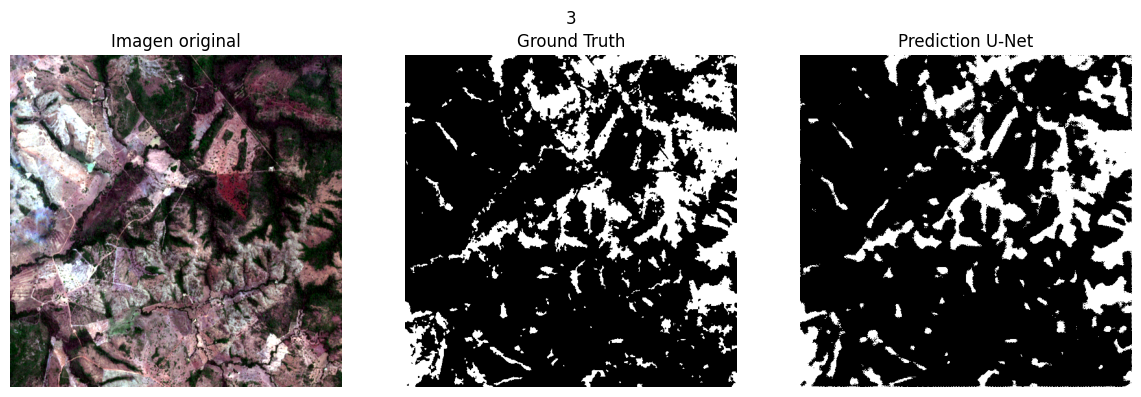

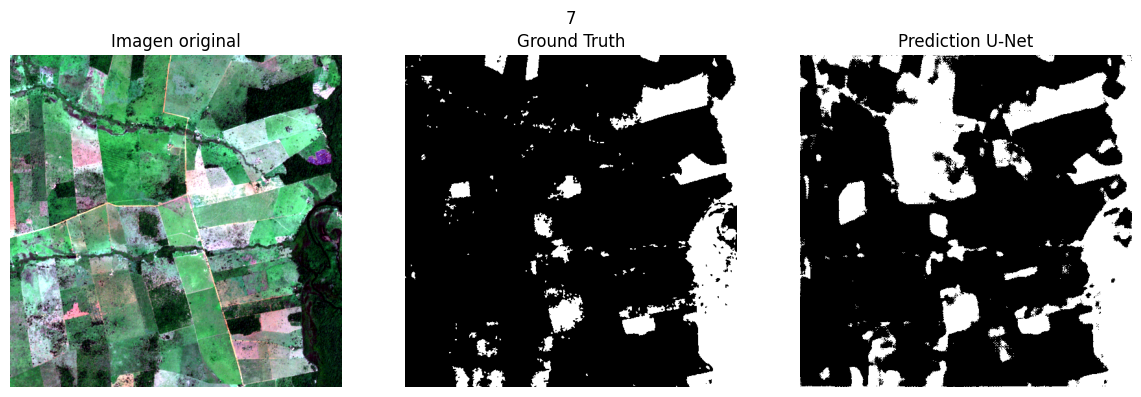

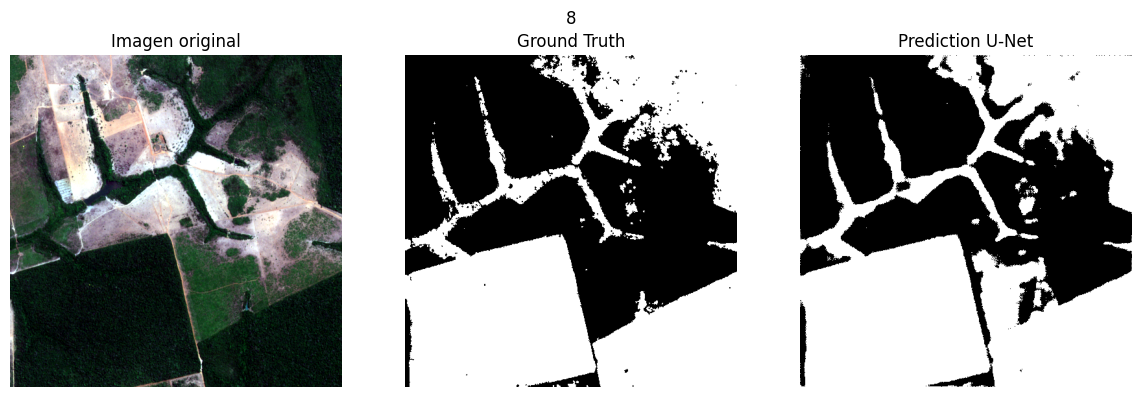

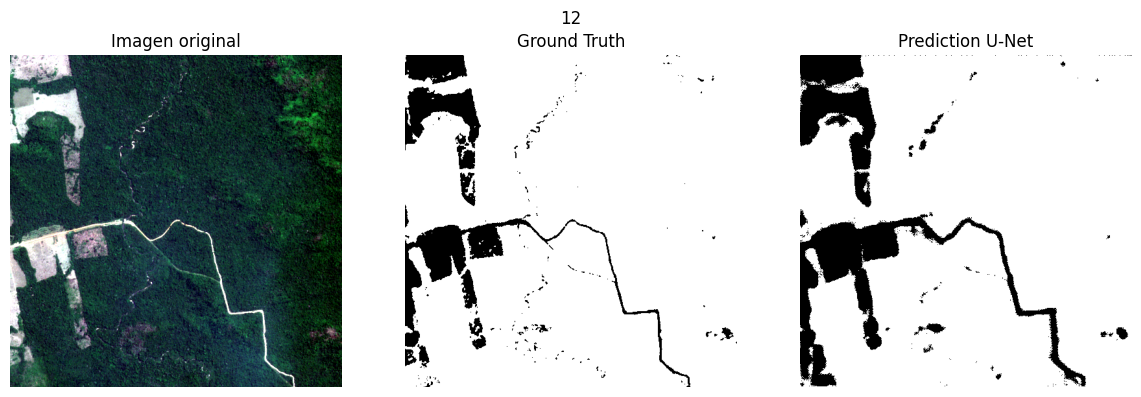

In [ ]:
# Elegir imágenes
indices = [1, 3, 7, 8, 12]

visualize_validation_examples(
    model_attunet,
    X_val,
    Y_val,
    indices,
    threshold=0.5
)